# PRODIGY_DS_03 — Decision Tree Classifier (Bank Marketing)
**Prodigy InfoTech — Data Science Internship, Task 03**

Task: Build a decision tree classifier to predict whether a customer will purchase a product or service based on their demographic and behavioral data, using the Bank Marketing dataset from UCI.

## 1. Import libraries & load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style("whitegrid")

!wget -q -O bank.csv https://raw.githubusercontent.com/YingluDeng/UCI_Bank_Marketing_ML/main/bank.csv
df = pd.read_csv("bank.csv")
print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 2. Inspect the target variable
`deposit`: did the client subscribe to a term deposit? (yes/no)

In [2]:
print(df["deposit"].value_counts())
print("\nClass balance:", df["deposit"].value_counts(normalize=True).to_dict())
print("\nMissing values:", df.isnull().sum().sum())

deposit
no     5873
yes    5289
Name: count, dtype: int64

Class balance: {'no': 0.5261601863465328, 'yes': 0.4738398136534671}

Missing values: 0


## 3. Preprocessing — encode categorical features
Decision trees split each feature independently on thresholds, so label encoding works fine (unlike with a linear model, there's no false ordinal assumption introduced).

In [3]:
df_encoded = df.copy()
categorical_cols = df_encoded.select_dtypes(include=["object", "str"]).columns.tolist()
print("Categorical columns:", categorical_cols)

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

X = df_encoded.drop(columns=["deposit"])
y = df_encoded["deposit"]
print("\nTarget encoding:", dict(zip(encoders["deposit"].classes_, encoders["deposit"].transform(encoders["deposit"].classes_))))

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

Target encoding: {'no': np.int64(0), 'yes': np.int64(1)}


## 4. Train/test split (80/20, stratified)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 8929 | Test size: 2233


## 5. Train the Decision Tree
`max_depth=5` is set deliberately to avoid overfitting and keep the tree readable when visualized.

In [5]:
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

## 6. Evaluate performance

In [6]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 Score:  {f1:.3f}")
print("\n", classification_report(y_test, y_pred, target_names=encoders["deposit"].classes_))

Accuracy:  0.807
Precision: 0.762
Recall:    0.862
F1 Score:  0.809

               precision    recall  f1-score   support

          no       0.86      0.76      0.81      1175
         yes       0.76      0.86      0.81      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



## 7. Confusion matrix

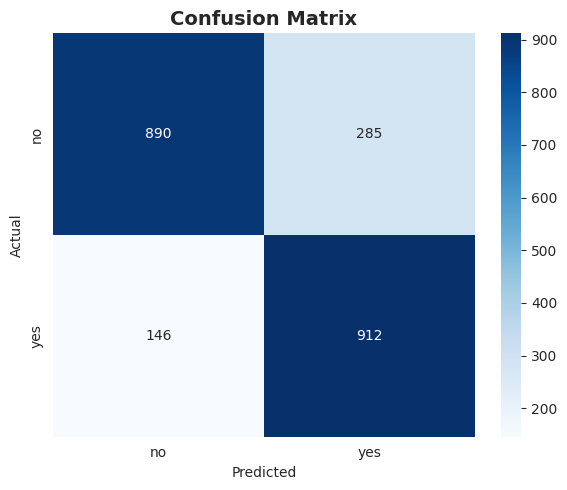

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoders["deposit"].classes_, yticklabels=encoders["deposit"].classes_)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 8. Feature importance

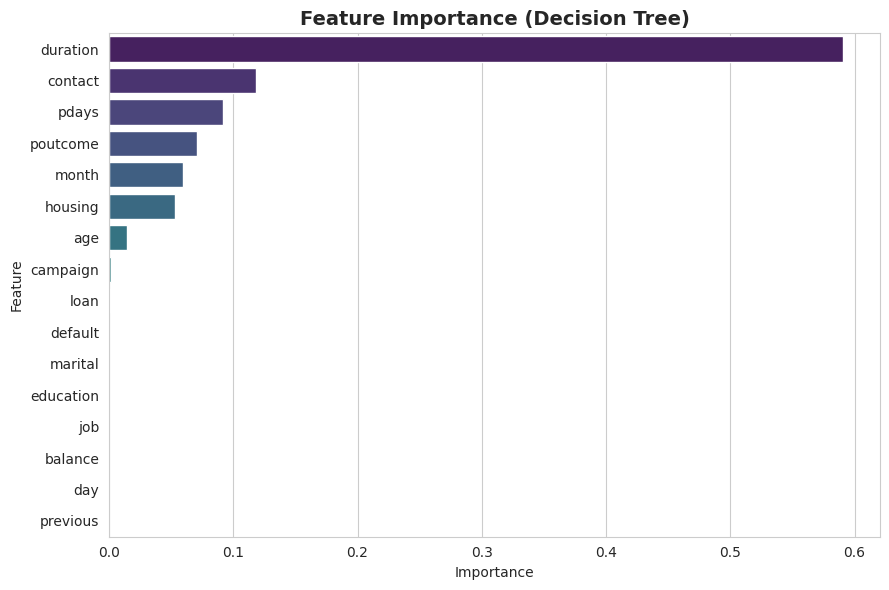

duration    0.590884
contact     0.118019
pdays       0.091840
poutcome    0.070537
month       0.059281
dtype: float64


In [8]:
importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, hue=importance.index, palette="viridis", legend=False)
plt.title("Feature Importance (Decision Tree)", fontsize=14, fontweight="bold")
plt.xlabel("Importance"); plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print(importance.head())

## 9. Visualize the tree (first 3 levels)

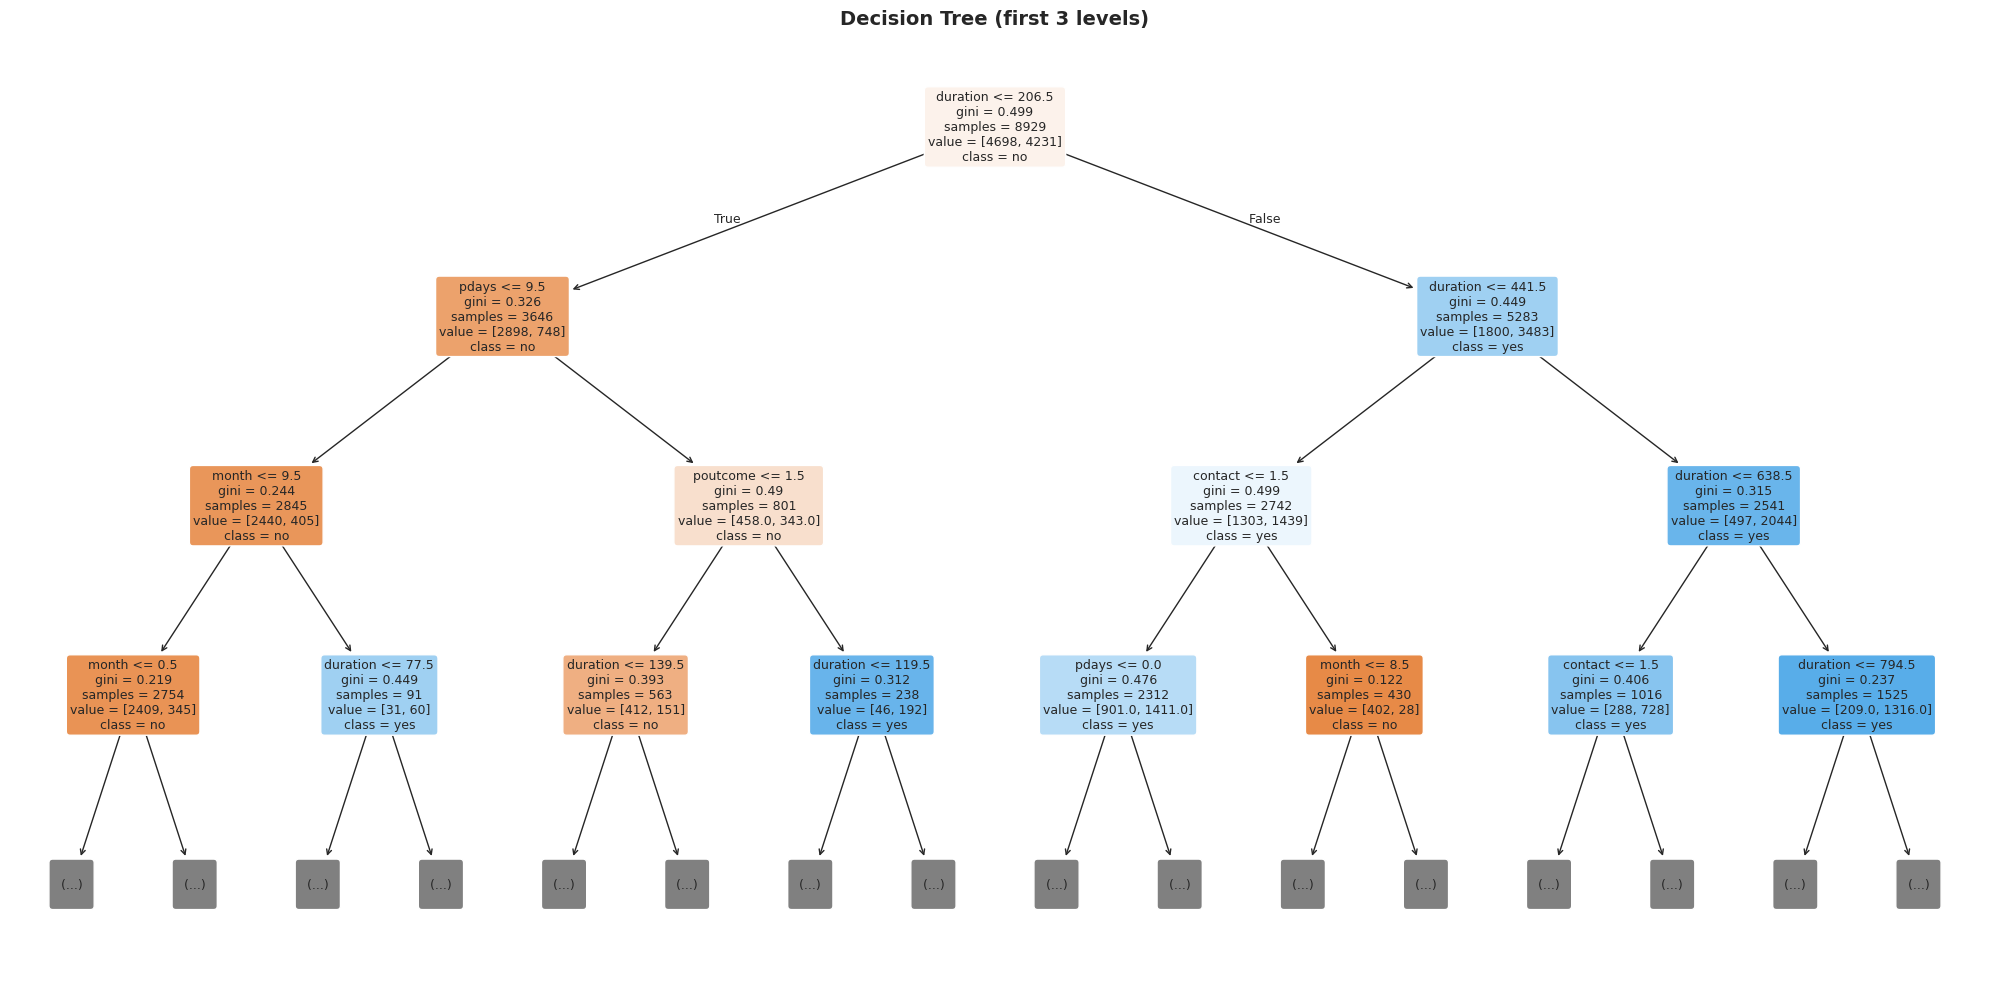

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(clf, max_depth=3, feature_names=X.columns, class_names=encoders["deposit"].classes_, filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (first 3 levels)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("decision_tree_plot.png", dpi=150)
plt.show()

## 10. Key Insights
- **Accuracy: 80.7%, F1: 0.809** — the model performs well on this reasonably balanced dataset (53% no / 47% yes).
- **Call `duration` dominates feature importance (~59%)** — longer calls strongly predict subscription, which makes intuitive sense: an engaged conversation signals real interest.
- **`contact` type, `pdays`, and `poutcome`** (prior campaign outcome) are the next most useful signals.
- **Demographics (age, job, education) matter far less** than behavioral/campaign features — *how* a client was engaged mattered more than *who* they are.

---
*Part of the Data Science Internship @ Prodigy InfoTech (Oct 2026)* #ProdigyInfoTech